**Project Title: Bike Sharing Demand Prediction**

**Problem Description**

Currently Rental bikes are introduced in many urban cities for the enhancement of mobility comfort. It is important to make the rental bike available and accessible to the public at the right time as it lessens the waiting time. Eventually, providing the city with a stable supply of rental bikes becomes a major concern. The crucial part is the prediction of bike count required at each hour for the stable supply of rental bikes.

**Data Description**

**The dataset contains weather information (Temperature, Humidity, Windspeed, Visibility, Dewpoint, Solar radiation, Snowfall, Rainfall), the number of bikes rented per hour and date information.**

**Attribute Information:**

Date: year-month-day

Rented Bike count- Count of bikes rented at each hour

Hour-Hour of he day

Temperature-Temperature in Celsius

Humidity-%

Windspeed-m/s

Visibility-10m

Dew point temperature - Celsius

Solar radiation-MJ/m2

Rainfall-mm

Snowfall-cm

In [50]:
#Loading Dataset and Importing important libraries
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [51]:
from datetime import datetime
import datetime as dt

In [52]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [54]:
from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import log_loss

In [55]:
import warnings
warnings.filterwarnings('ignore')

**Import the dataset**

In [56]:
#let's import the dataset
bike_df=pd.read_csv("1776241192-P4-Bike Sharing Demand Prediction.csv",encoding='latin-1')

**Understand more about Data**

Summary of data

In [57]:
#Viewing the data of top 5 rows to take a glimps of the data
bike_df.head()

,Date,Rented Bike Count,Hour,Temperature(Â°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(Â°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [58]:
#View the data of bottom 5 rows to take glimps of the data
bike_df.tail()

,Date,Rented Bike Count,Hour,Temperature(Â°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(Â°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
8759,30/11/2018,584,23,1.9,43,1.3,1909,-9.3,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [59]:
#Getting the shape of the dataset with rows and columns
print(bike_df.shape)

(8760, 14)


In [60]:
#Getting all the columns 
print("Features of the dataset :")
bike_df.columns

Features of the dataset :


Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(Â°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(Â°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='object')

In [61]:
#Check details about the data set
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        8760 non-null   object 
 1   Rented Bike Count           8760 non-null   int64  
 2   Hour                        8760 non-null   int64  
 3   Temperature(Â°C)            8760 non-null   float64
 4   Humidity(%)                 8760 non-null   int64  
 5   Wind speed (m/s)            8760 non-null   float64
 6   Visibility (10m)            8760 non-null   int64  
 7   Dew point temperature(Â°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)     8760 non-null   float64
 9   Rainfall(mm)                8760 non-null   float64
 10  Snowfall (cm)               8760 non-null   float64
 11  Seasons                     8760 non-null   object 
 12  Holiday                     8760 non-null   object 
 13  Functioning Day             8760 

In [62]:
#Print the unique values
bike_df.nunique()

Date                           365
Rented Bike Count             2166
Hour                            24
Temperature(Â°C)               546
Humidity(%)                     90
Wind speed (m/s)                65
Visibility (10m)              1789
Dew point temperature(Â°C)     556
Solar Radiation (MJ/m2)        345
Rainfall(mm)                    61
Snowfall (cm)                   51
Seasons                          4
Holiday                          2
Functioning Day                  2
dtype: int64

In [63]:
#Looking for the description of the dataset to get insights of the data
bike_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rented Bike Count,8760.0,704.602055,644.997468,0.0,191.00,504.50,1065.25,3556.00
Hour,8760.0,11.500000,6.922582,0.0,5.75,11.50,17.25,23.00
Temperature(Â°C),8760.0,12.882922,11.944825,-17.8,3.50,13.70,22.50,39.40
Humidity(%),8760.0,58.226256,20.362413,0.0,42.00,57.00,74.00,98.00
Wind speed (m/s),8760.0,1.724909,1.036300,0.0,0.90,1.50,2.30,7.40
Visibility (10m),8760.0,1436.825799,608.298712,27.0,940.00,1698.00,2000.00,2000.00
Dew point temperature(Â°C),8760.0,4.073813,13.060369,-30.6,-4.70,5.10,14.80,27.20
Solar Radiation (MJ/m2),8760.0,0.569111,0.868746,0.0,0.00,0.01,0.93,3.52
Rainfall(mm),8760.0,0.148687,1.128193,0.0,0.00,0.00,0.00,35.00
Snowfall (cm),8760.0,0.075068,0.436746,0.0,0.00,0.00,0.00,8.80


1. This Dataset contains 8760 rows and 14 columns.

2. In a day we have 24 hours and 365 days a year to a 365 multiplied 24 = 8670, which represents the number of the rows in the dataset.

**Missing Values**

In [64]:
#Check for count of missing values in the dataset
bike_df.isna().sum()
bike_df.isnull().sum()

Date                          0
Rented Bike Count             0
Hour                          0
Temperature(Â°C)              0
Humidity(%)                   0
Wind speed (m/s)              0
Visibility (10m)              0
Dew point temperature(Â°C)    0
Solar Radiation (MJ/m2)       0
Rainfall(mm)                  0
Snowfall (cm)                 0
Seasons                       0
Holiday                       0
Functioning Day               0
dtype: int64

**As we can see that  there are no missing Values.**

**Duplicate Values**

Why is  it important to remove duplicate records from my data?

Duplication just means that you have repeated data in your dataset. This could be due to things like data entry errors or data collection methods by removing duplication in our dataset, Time and Money are saved by not sending identical communications multiple times to the same person. 

In [65]:
#Checking duplicate values
value=len(bike_df[bike_df.duplicated()])
print("The Number of duplicate values in the data set is = ", value)

The Number of duplicate values in the data set is =  0


**Changing column name**

In [66]:
#Rename the complex columns name
bike_df=bike_df.rename(columns={'Rented Bike Count': 'Rented_Bike_Count', 'Temperature(Â°C)': 'Temperature','Humidity(%)': 'Humidity','Wind speed (m/s)': 'Wind_speed','Visibility (10m)': 'Visibility','Dew point temperature(Â°C)': 'Dew_point_temperature','Solar Radiation (MJ/m2)': 'Solar_Radiation','Rainfall(mm)': 'Rainfall','Snowfall (cm)': 'Snowfall','Functioning Day': 'Functioning_Day'})

Python read "Date" column as a object type basically it reads as a string, as the date column is very important to analyse the users behaviour so we need to convert it into datetime format then we split it into 3 column i.e 'year', 'month', 'day'as a category data type.

**Breaking Date Column**

In [67]:
#Changing the "Date" column into three "year", "month", "day" column
bike_df['Date'] = bike_df['Date'].apply(lambda x:dt.datetime.strptime(x, "%d/%m/%Y"))

In [68]:
bike_df['year'] = bike_df['Date'].dt.year
bike_df['month'] = bike_df['Date'].dt.month
bike_df['day'] = bike_df['Date'].dt.day_name()

In [69]:
#Creating a new column of "weekdays_weekend" and drop the column "Date", "day", "year"
bike_df['weekdays_weekend']=bike_df['day'].apply(lambda x : 1 if x =='Saturday' or x== 'Sunday' else 0)
bike_df=bike_df.drop(columns=['Date', 'day', 'year'], axis=1)

So we convert the "date" column into 3 different column  i.e "year","month","day".

The "year" column in our data set is basically contain the 2 unique number contains the details of from 2017 december to 2018 november so if i consider this is a one year then we don't need the "year" column so we drop it.


The other column "day", it contains the details about each day of the month, for our relevance we don't need each day of each month data but we need the data about, if a day is a weekday or a weekend so we convert it into this format and drop the "day" column

In [70]:
bike_df.head()

,Rented_Bike_Count,Hour,Temperature,Humidity,Wind_speed,Visibility,Dew_point_temperature,Solar_Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning_Day,month,weekdays_weekend
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,0
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,0
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,12,0
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,0
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,0


In [71]:
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Rented_Bike_Count      8760 non-null   int64  
 1   Hour                   8760 non-null   int64  
 2   Temperature            8760 non-null   float64
 3   Humidity               8760 non-null   int64  
 4   Wind_speed             8760 non-null   float64
 5   Visibility             8760 non-null   int64  
 6   Dew_point_temperature  8760 non-null   float64
 7   Solar_Radiation        8760 non-null   float64
 8   Rainfall               8760 non-null   float64
 9   Snowfall               8760 non-null   float64
 10  Seasons                8760 non-null   object 
 11  Holiday                8760 non-null   object 
 12  Functioning_Day        8760 non-null   object 
 13  month                  8760 non-null   int32  
 14  weekdays_weekend       8760 non-null   int64  
dtypes: f

In [72]:
bike_df['weekdays_weekend'].value_counts()

weekdays_weekend
0    6264
1    2496
Name: count, dtype: int64

**Changing data type**

As "Hour","month","weekdays_weekend" column are shown as a integer data type but actually it is a category data type, so we need to change this data type if we didnt do that then, while doing the further analysis and correlation with this data then the values are not actually true so we can mislead by this.

In [73]:
bike_df.nunique()

Rented_Bike_Count        2166
Hour                       24
Temperature               546
Humidity                   90
Wind_speed                 65
Visibility               1789
Dew_point_temperature     556
Solar_Radiation           345
Rainfall                   61
Snowfall                   51
Seasons                     4
Holiday                     2
Functioning_Day             2
month                      12
weekdays_weekend            2
dtype: int64

In [74]:
#Change the int64 column into the category column
cols=['Hour', 'month', 'weekdays_weekend']
for col in cols:
    bike_df[col]=bike_df[col].astype('category')

In [75]:
#let's check the result of data type
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Rented_Bike_Count      8760 non-null   int64   
 1   Hour                   8760 non-null   category
 2   Temperature            8760 non-null   float64 
 3   Humidity               8760 non-null   int64   
 4   Wind_speed             8760 non-null   float64 
 5   Visibility             8760 non-null   int64   
 6   Dew_point_temperature  8760 non-null   float64 
 7   Solar_Radiation        8760 non-null   float64 
 8   Rainfall               8760 non-null   float64 
 9   Snowfall               8760 non-null   float64 
 10  Seasons                8760 non-null   object  
 11  Holiday                8760 non-null   object  
 12  Functioning_Day        8760 non-null   object  
 13  month                  8760 non-null   category
 14  weekdays_weekend       8760 non-null   c

In [76]:
bike_df.columns


Index(['Rented_Bike_Count', 'Hour', 'Temperature', 'Humidity', 'Wind_speed',
       'Visibility', 'Dew_point_temperature', 'Solar_Radiation', 'Rainfall',
       'Snowfall', 'Seasons', 'Holiday', 'Functioning_Day', 'month',
       'weekdays_weekend'],
      dtype='object')

In [77]:
bike_df['weekdays_weekend'].unique()

[0, 1]
Categories (2, int64): [0, 1]

**Exploratory Data Analysis of The Dataset**

[Text(0.5, 1.0, 'Count of Rented bikes according to Month')]

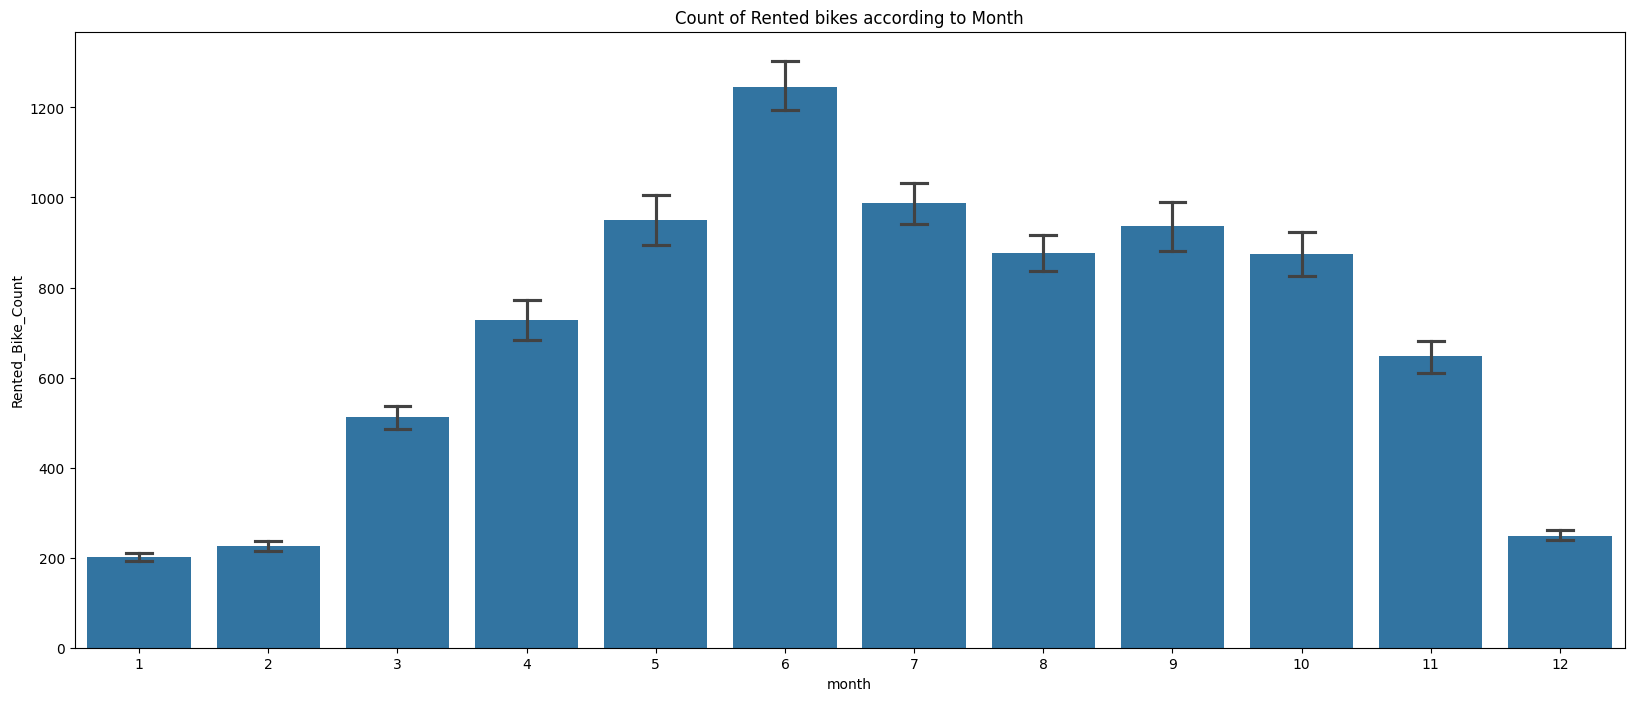

In [78]:
#analysis of data by visualization
fig,ax=plt.subplots (figsize=(20,8))
sns.barplot(data=bike_df,x='month', y='Rented_Bike_Count',ax=ax,capsize=.2)
ax.set(title='Count of Rented bikes according to Month')

From the above bar plot we can clearly say that from the month 5 to 10 the demand of the rented bike is high as compared to other months. These months comes under summer season.

**weekdays_weekend**

[Text(0.5, 1.0, 'Count of Rented bikes according to weekdays and weekend')]

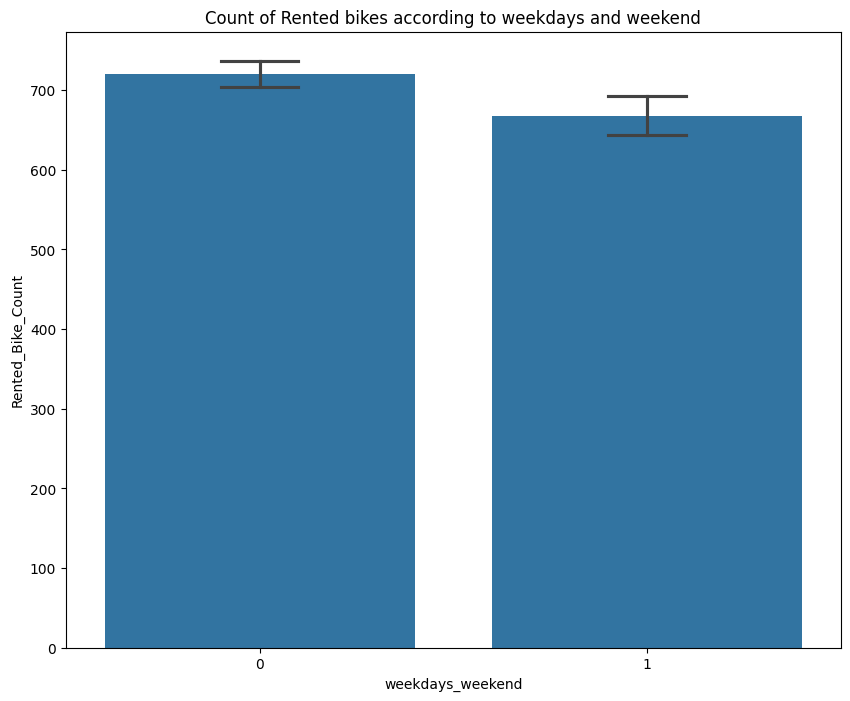

In [79]:
#analysis of data by visualization
fig,ax=plt.subplots (figsize=(10,8))
sns.barplot(data=bike_df,x='weekdays_weekend', y='Rented_Bike_Count',ax=ax,capsize=.2)
ax.set(title='Count of Rented bikes according to weekdays and weekend')

[Text(0.5, 1.0, 'Count of Rented bikes according to weekdays_weekend ')]

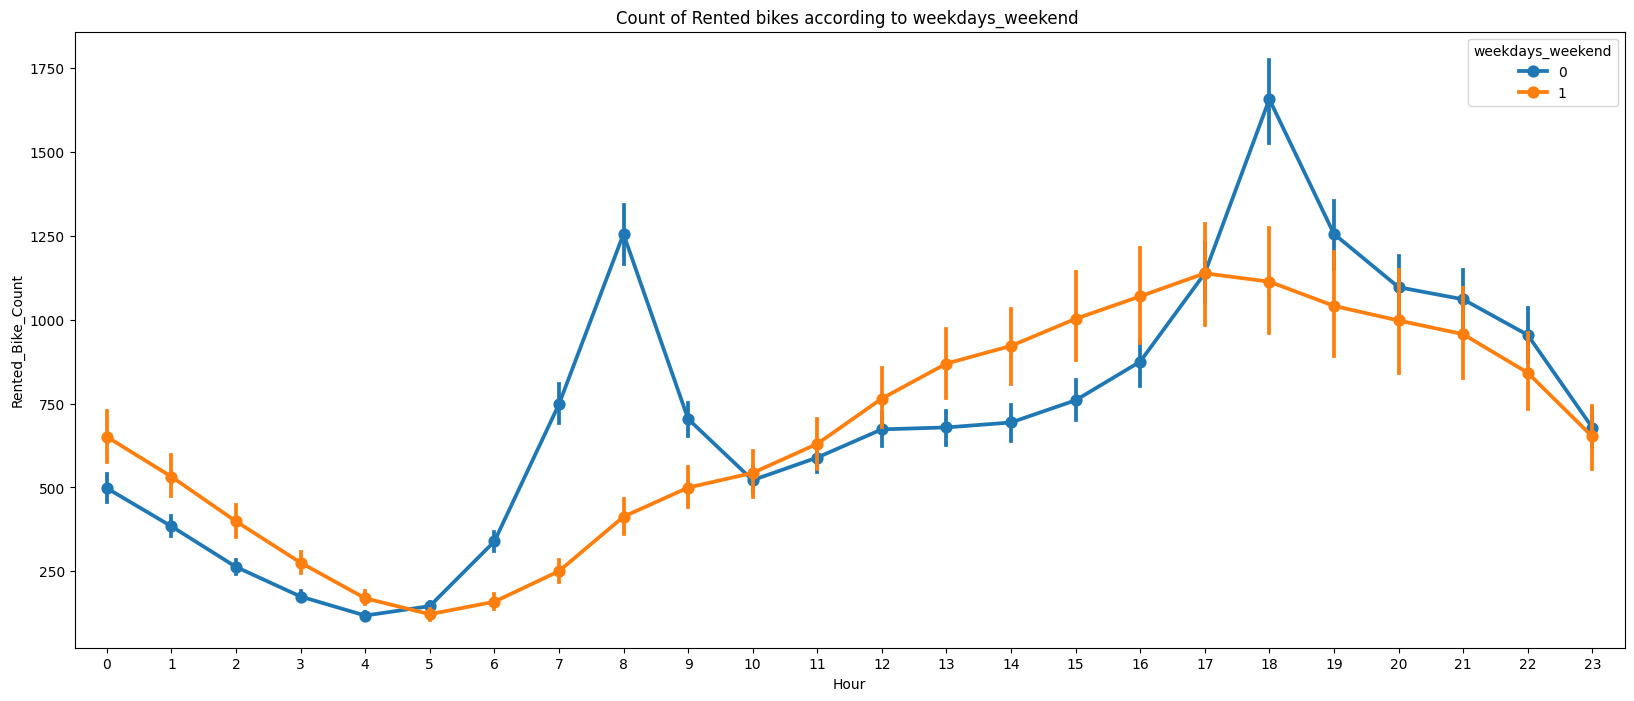

In [80]:
#analysis of data by visualization
fig,ax=plt.subplots (figsize=(20,8))
sns.pointplot(data=bike_df,x= 'Hour', y='Rented_Bike_Count', hue='weekdays_weekend', ax=ax)
ax.set(title='Count of Rented bikes according to weekdays_weekend ')

1. From the above point plot and bar plot we can say that in the week days which represent in blue color show that the demand of the bike is higher because of the office.

2. Peak Time is 7 am to 9 am and 5 pm to 7 pm

3. The orange colour represents the weekend days, and it shows that the demand for rented bikes is very low especially in the morning hour but when the evening starts from 4 pm to 8 pm the demand slightly increases.

**Hour**

[Text(0.5, 1.0, 'Count of Rented bikes according to Hour')]

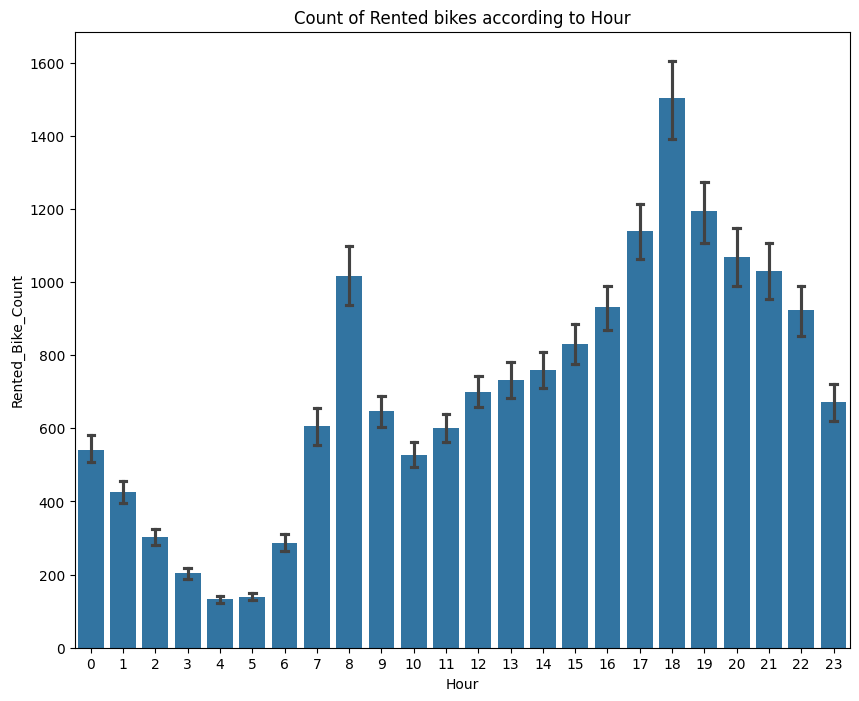

In [81]:
#analysis of data by visualization
fig,ax=plt.subplots (figsize=(10,8))
sns.barplot(data=bike_df,x='Hour', y='Rented_Bike_Count',ax=ax,capsize=.2)
ax.set(title='Count of Rented bikes according to Hour')

In the above plot which shows the use of rented bikes according to the hours and the data are from all over the year.

Generally people use rented bikes during their working hours from 7am to 9am and 5pm to 7pm

**Functioning Day**

[Text(0.5, 1.0, 'Count of Rented bikes according to Functioning Day')]

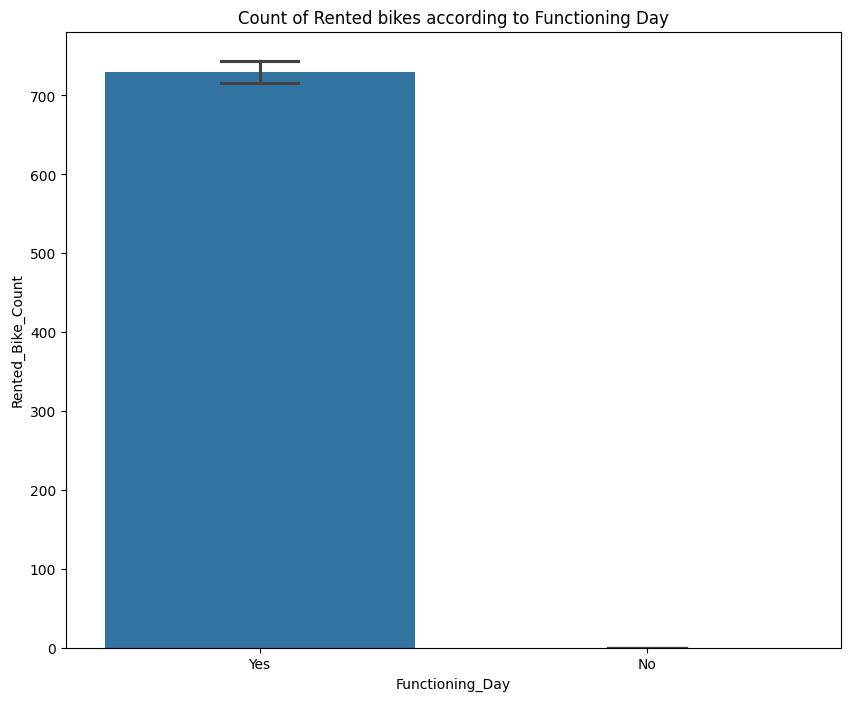

In [82]:
#analysis of data by visualization
fig,ax=plt.subplots (figsize=(10,8))
sns.barplot(data=bike_df,x='Functioning_Day', y='Rented_Bike_Count',ax=ax,capsize=.2)
ax.set(title='Count of Rented bikes according to Functioning Day')

[Text(0.5, 1.0, 'Count of Rented bikes according to Functioning Day')]

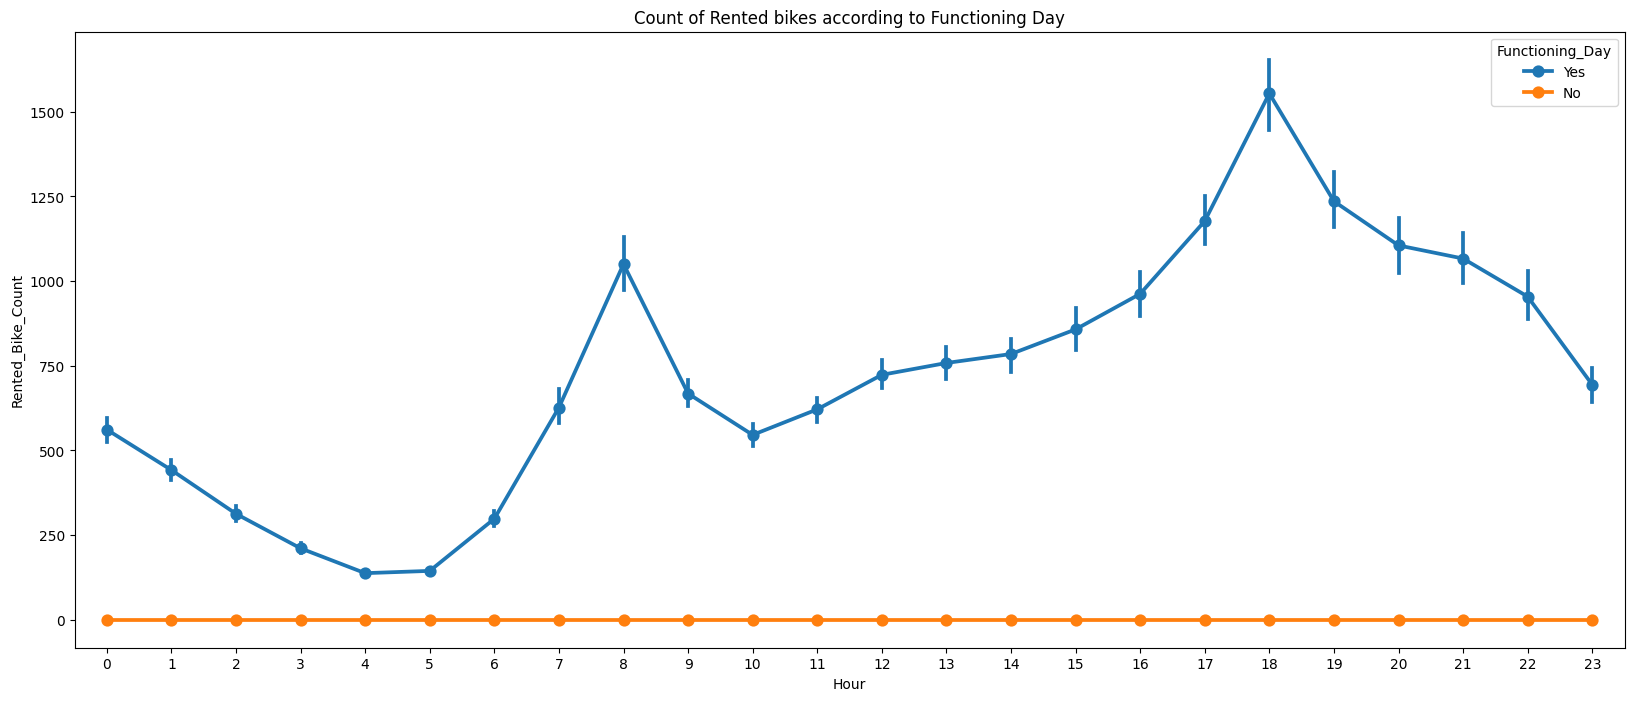

In [83]:
#analysis of data by visualization
fig,ax=plt.subplots (figsize=(20,8))
sns.pointplot(data=bike_df,x= 'Hour', y='Rented_Bike_Count', hue='Functioning_Day', ax=ax)
ax.set(title='Count of Rented bikes according to Functioning Day')

In the above bar plot and point plot which shows the use of rented bikes in functioning daya or not, and it clearly shows that,People don't use rented bikes in non-functioning days.

**Seasons**

[Text(0.5, 1.0, 'Count of Rented bikes according to Seasons')]

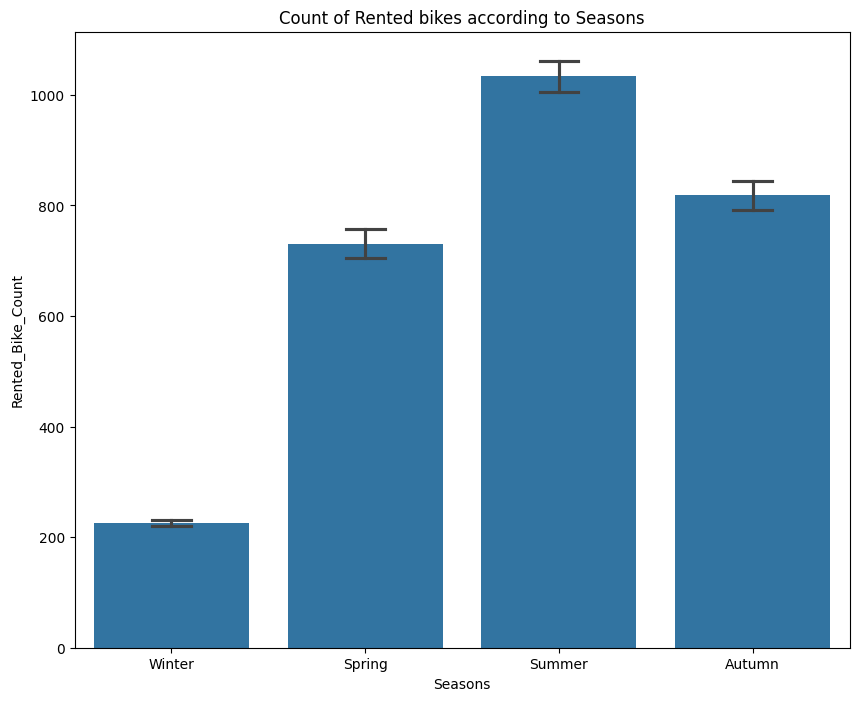

In [84]:
#analysis of data by visualization
fig,ax=plt.subplots (figsize=(10,8))
sns.barplot(data=bike_df,x='Seasons', y='Rented_Bike_Count',ax=ax,capsize=.2)
ax.set(title='Count of Rented bikes according to Seasons')

[Text(0.5, 1.0, 'Count of Rented bikes according to Seasons')]

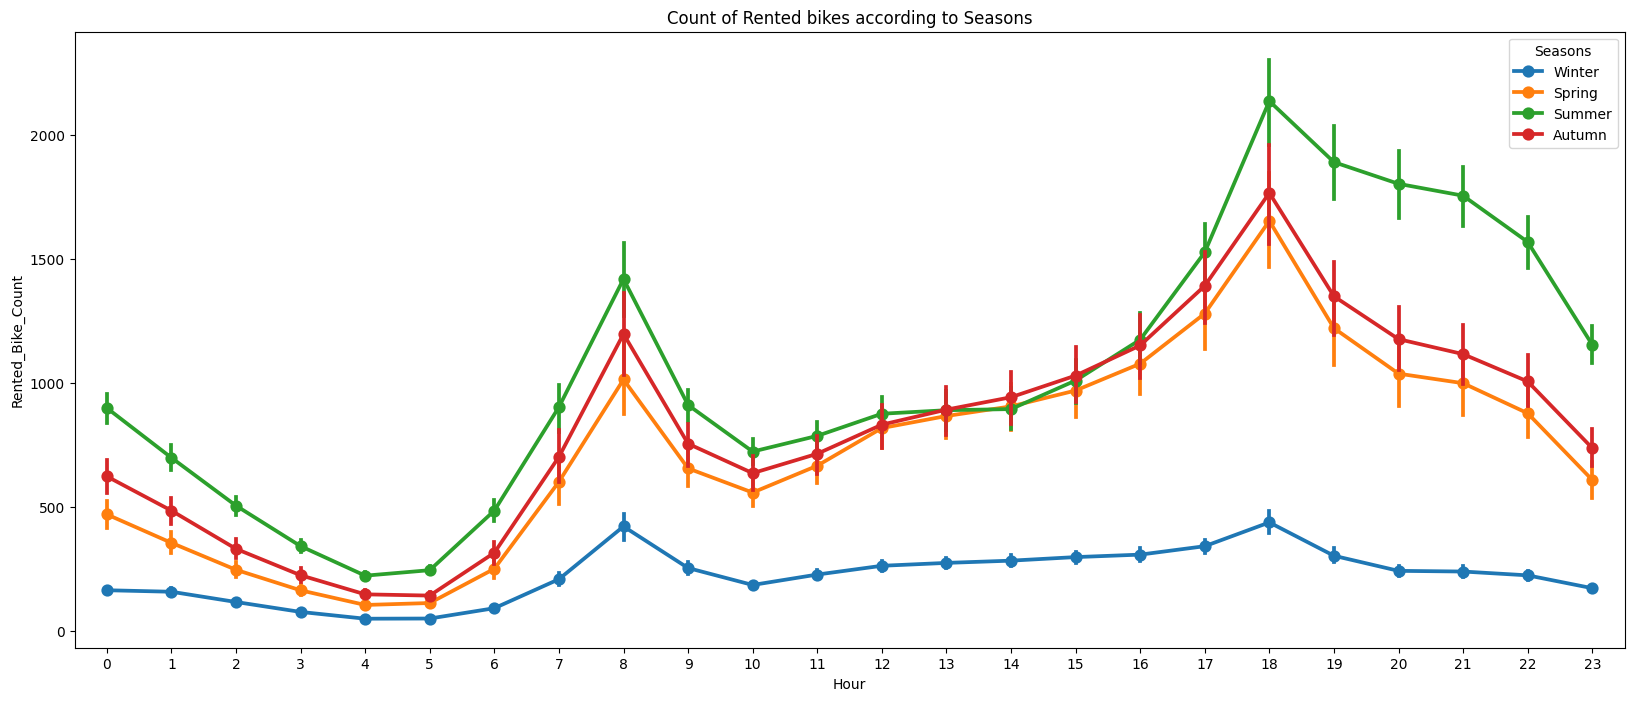

In [85]:
#analysis of data by visualization
fig,ax=plt.subplots (figsize=(20,8))
sns.pointplot(data=bike_df,x= 'Hour', y='Rented_Bike_Count', hue='Seasons', ax=ax)
ax.set(title='Count of Rented bikes according to Seasons')

In the above bar plot and point plot which shows the use of rented bikes in four different seasons, and it clearly shows that:

1. In the summer season the use of rented bikes is high and peak time is 7am-9am and 7pm-5pm.

2. In the winter season the use of rented bikes is very low because of snowfall.

**Holiday**

[Text(0.5, 1.0, 'Count of Rented bikes according to Holiday')]

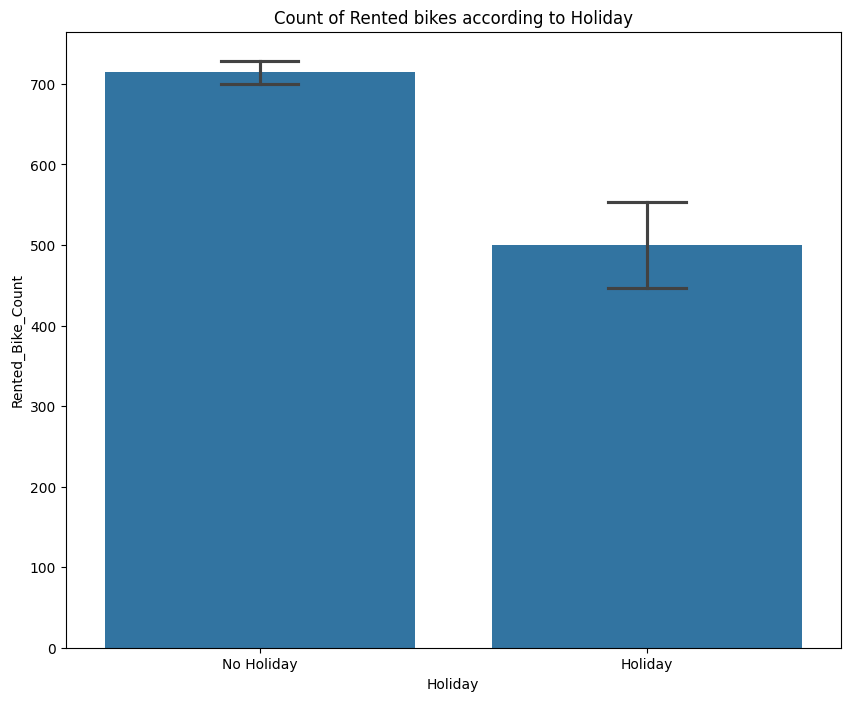

In [86]:
#analysis of data by visualization
fig,ax=plt.subplots (figsize=(10,8))
sns.barplot(data=bike_df,x='Holiday', y='Rented_Bike_Count',ax=ax,capsize=.2)
ax.set(title='Count of Rented bikes according to Holiday')

[Text(0.5, 1.0, 'Count of Rented bikes according to Holiday')]

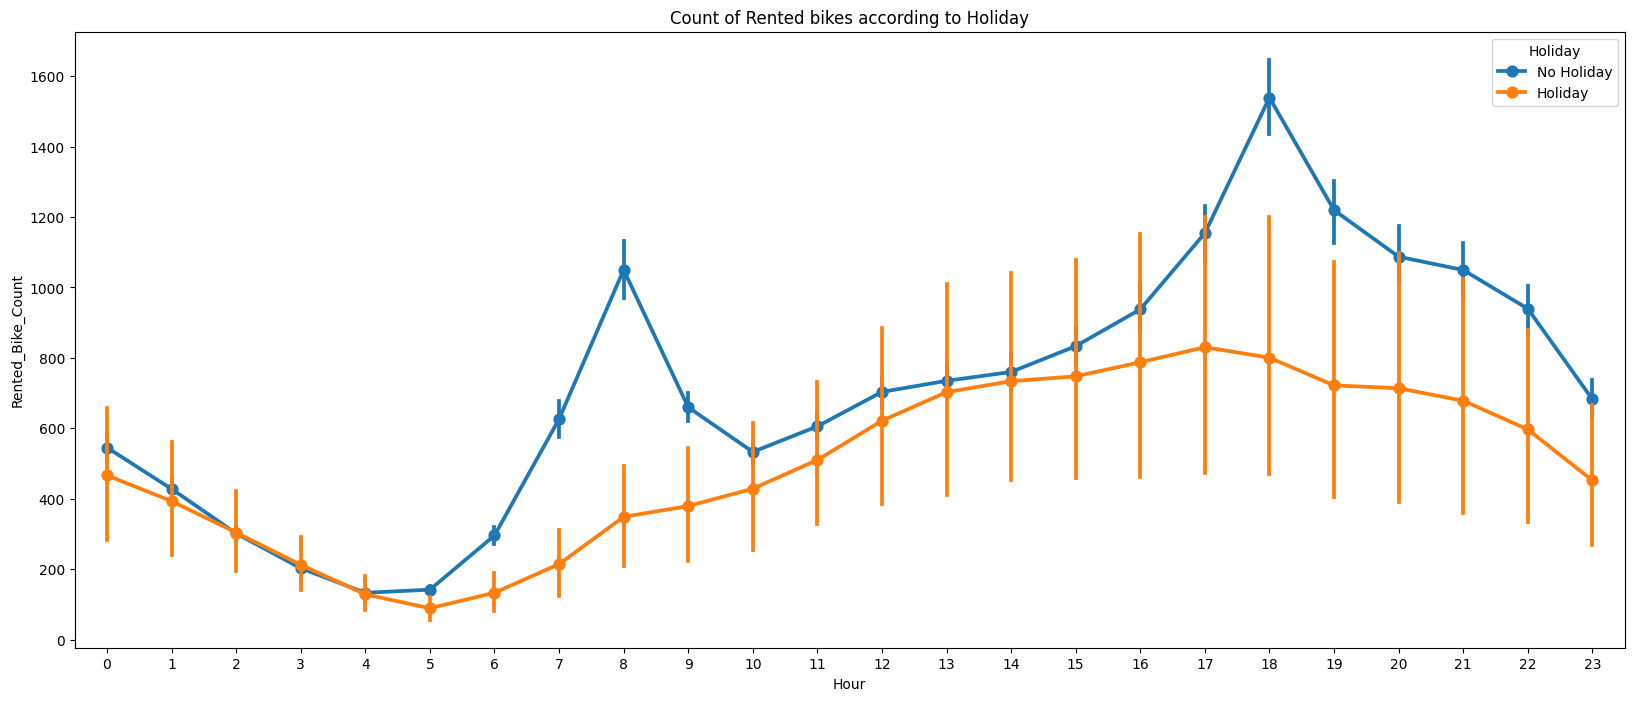

In [87]:
#analysis of data by visualization
fig,ax=plt.subplots (figsize=(20,8))
sns.pointplot(data=bike_df,x= 'Hour', y='Rented_Bike_Count', hue='Holiday', ax=ax)
ax.set(title='Count of Rented bikes according to Holiday')

In the above bar plot and point plot which shows the use of rented bikes on holiday, and it clearly shows that,  plot shows that in holidays people use the rented bike from 2pm-8pm.

**Analysis of Numerical variables**


In [88]:
#assign the numerical column to variable
numerical_columns=list(bike_df.select_dtypes(['int64','float64']).columns)
numerical_features=pd. Index (numerical_columns)
numerical_features

Index(['Rented_Bike_Count', 'Temperature', 'Humidity', 'Wind_speed',
       'Visibility', 'Dew_point_temperature', 'Solar_Radiation', 'Rainfall',
       'Snowfall'],
      dtype='object')

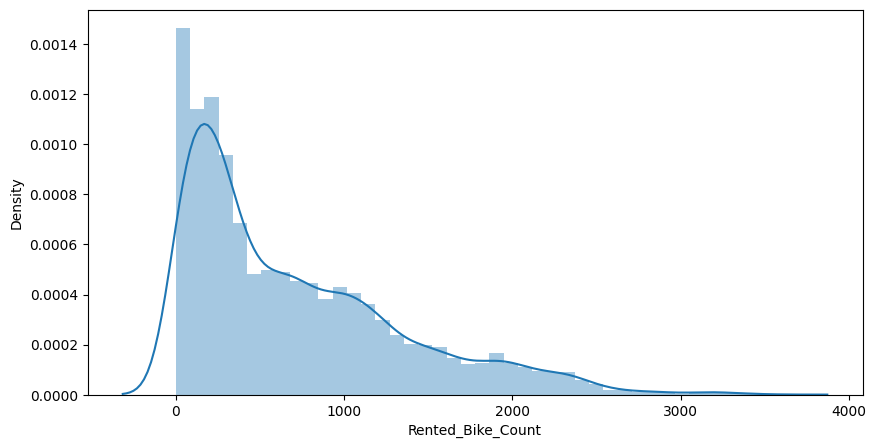

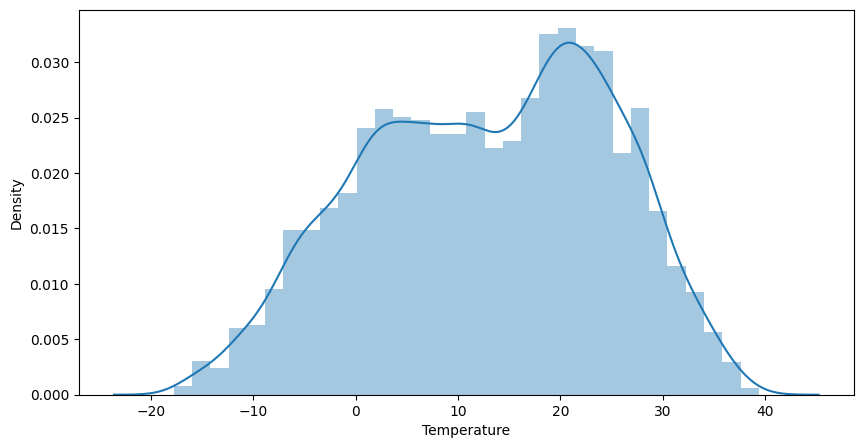

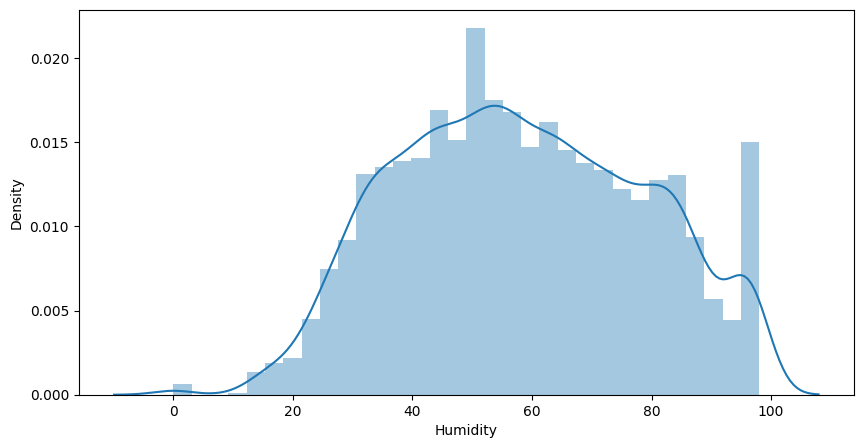

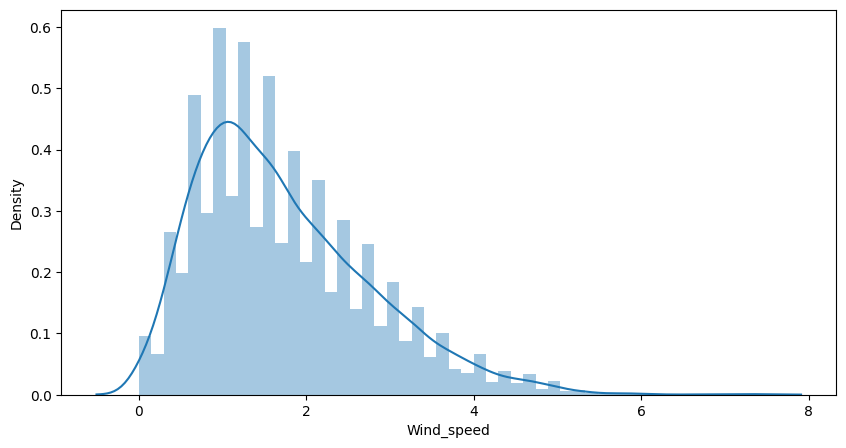

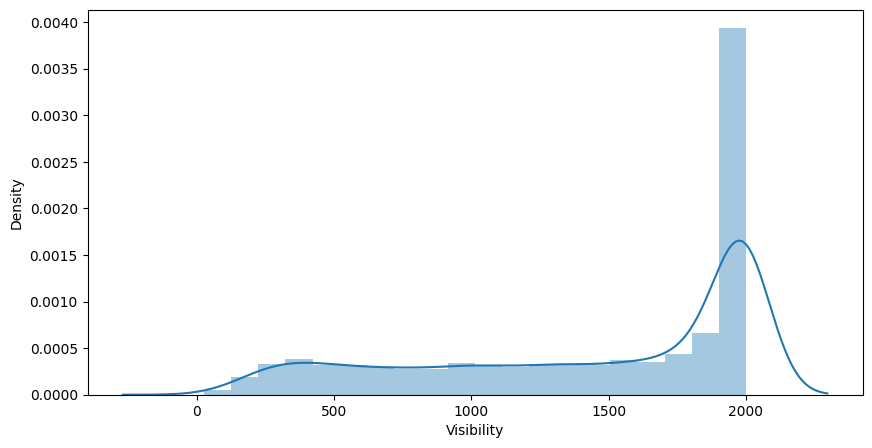

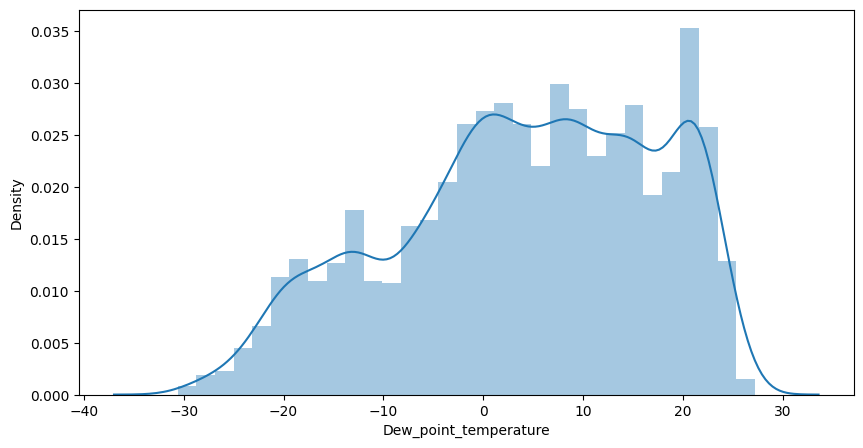

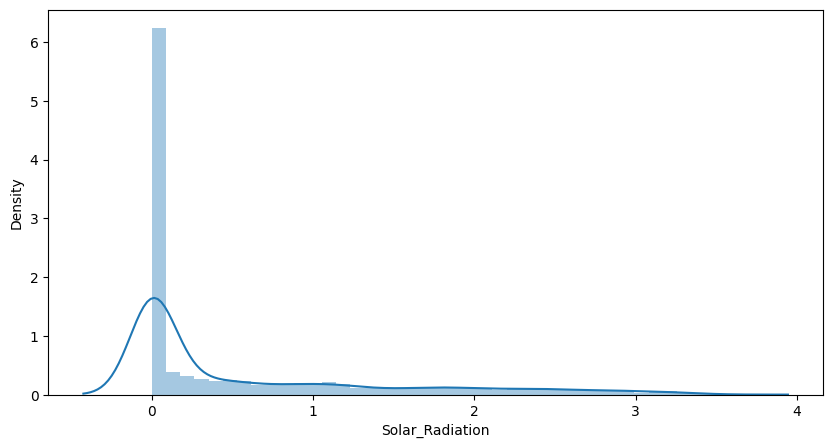

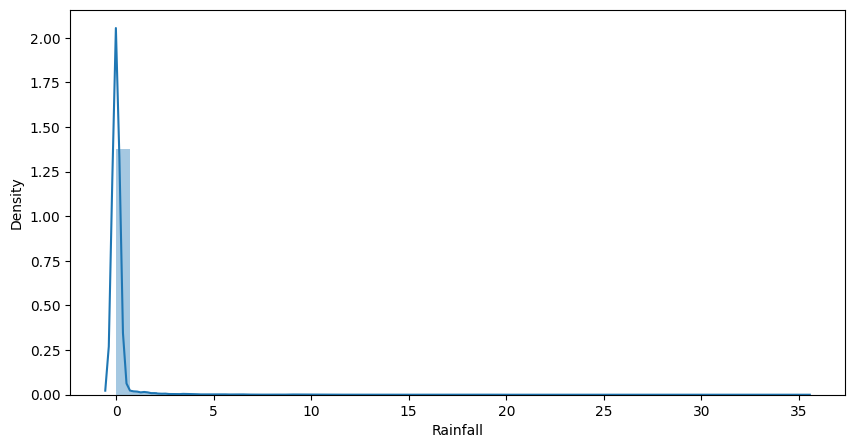

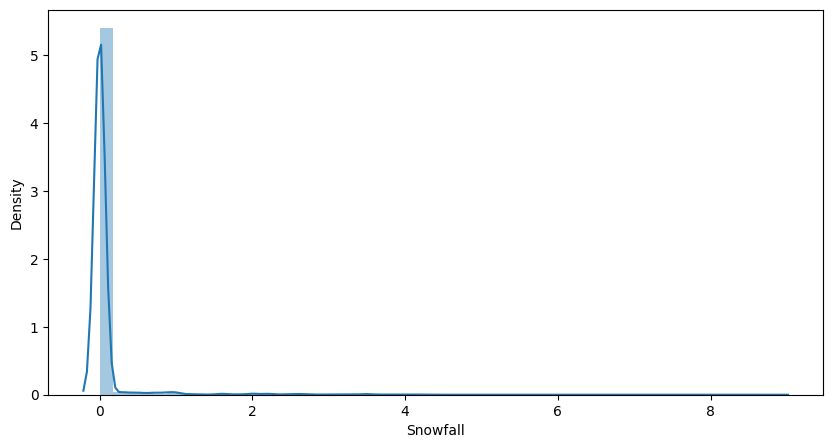

In [89]:
#printing distplots to analyse the distribution of all numerical features
for col in numerical_features:
    plt.figure(figsize=(10,5))
    sns.distplot(x=bike_df[col])
    plt.xlabel(col)
plt.show()

**Numerical Vs. Rented_Bike_Count**

<Axes: xlabel='Temperature'>

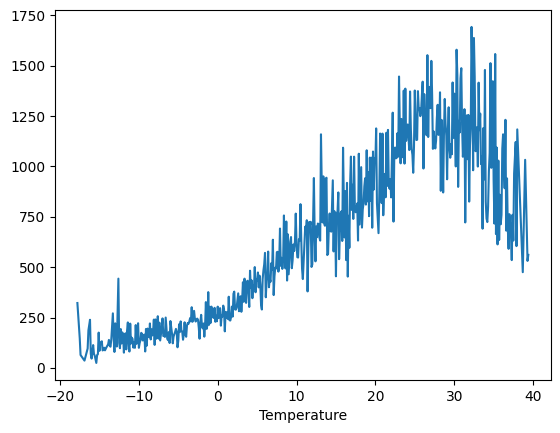

In [90]:
#print the plot to analyse the relationship between "Rented Bike Count" and "Temperature" 
bike_df.groupby('Temperature')['Rented_Bike_Count'].mean().plot()
#Removed extra .mean() that was causing the issue

From the above plot we see that people like to ride bikes when it is pretty hot around 25°C in average.

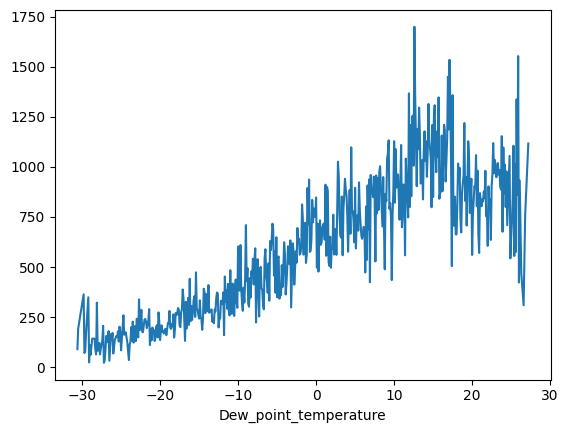

In [91]:
#print the plot to analyse the relationship between "Rented_Bike_Count" and "Dew_point_temperature" 
bike_df.groupby('Dew_point_temperature') ['Rented_Bike_Count'].mean().plot()

#Convert 'Dew_point_temperature' to numeric before calculating the mean if it's categorical 
bike_df[ 'Dew_point_temperature'] = bike_df[ 'Dew_point_temperature'].astype(float)

From the above plot of "Dew_point_temperature' is almost the same as the 'temperature' there is some similarity present we can check it in our next step.

<Axes: xlabel='Solar_Radiation'>

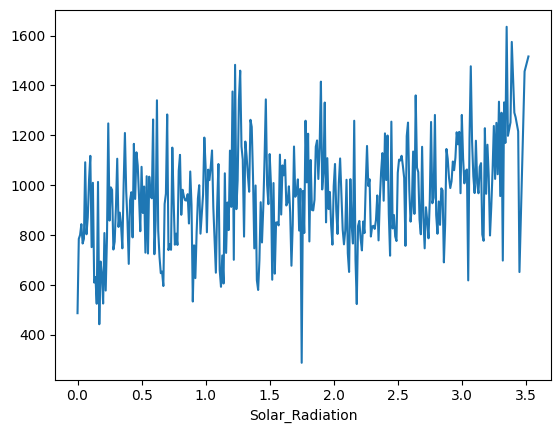

In [92]:
#print the plot to analyse the relationship between "Rented_Bike_Count" and "Solar_Radiation"
bike_df[ 'Solar_Radiation'] = bike_df[ 'Solar_Radiation'].astype(float)  # Convert 'Solar_Radiation' to a numeric type 
bike_df.groupby('Solar_Radiation') ['Rented_Bike_Count'].mean().plot()

From the above plot we see that, the amount of rented bikes is huge, when there is solar radiation, the counter of rent is around 1000.

<Axes: xlabel='Wind_speed'>

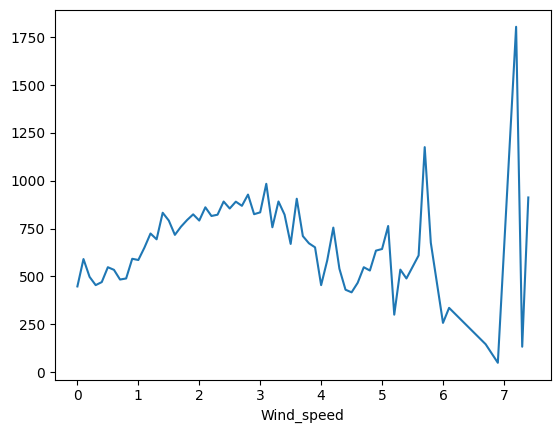

In [93]:
#prins the plot to analyze the relationship between "Rented_Bike_count and Wind_speed
bike_df.groupby('Wind_speed')['Rented_Bike_Count'].mean().plot() #Calculate the mean of 'Rented Bike Count' for each wind speed category

We can see from the above plot that the demand of rented bikes is uniformly distributed despite wind speed but when the speed of wind was 7 m/s then the demand of bike also increase that clearly means peoples love to ride bikes when its little windy.

**Regression plot**

The regression plots in seaborn are primarily intended to add a visual guide that helps to emphasize patterns in a dataset during exploratory data analyses. Regression plots as the name suggests creates a regression line between 2 parameters and helps to visualize their linear relationships.


**Normalise Rented_Bike_Count column data**

The data normalization (also referred to as data pre-processing) is a basic element of data mining. It means transforming the data, namely converting the source data into another format that allows processing data effectively. The main purpose of data normalization is to minimize or even exclude duplicated data.

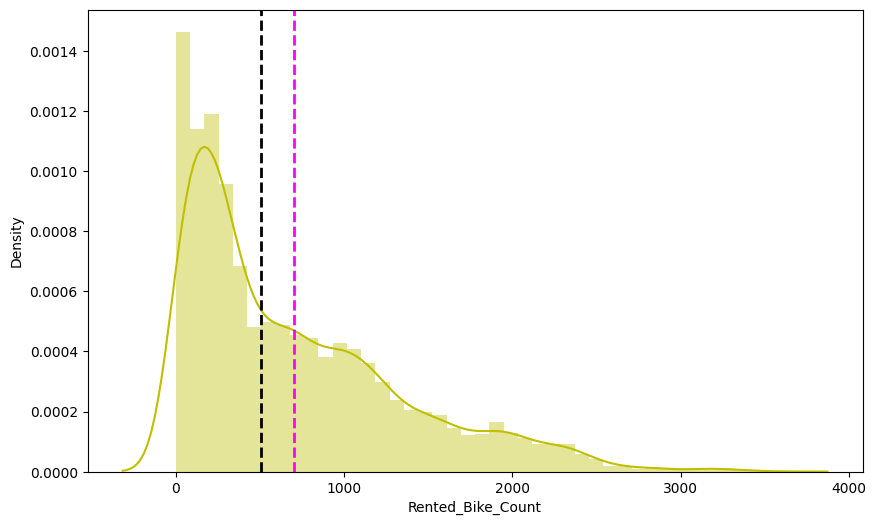

In [94]:
#Distribution plot of Rented Bike Count
plt.figure(figsize=(10,6))
plt.xlabel('Rented_Bike_Count')
plt.ylabel('Density')
ax= sns.distplot(bike_df['Rented_Bike_Count'],hist=True,color='y')
ax.axvline(bike_df['Rented_Bike_Count'].mean(), color='magenta', linestyle='dashed', linewidth=2)
ax.axvline(bike_df['Rented_Bike_Count'].median(), color='black', linestyle='dashed', linewidth=2)
plt.show()


The above graph shows the Rented Bike Count has moderate right skewness. Since the assumption of linear regression is that "the distribution of dependent variable has to be normal", so we should perform some operation to make it normal.

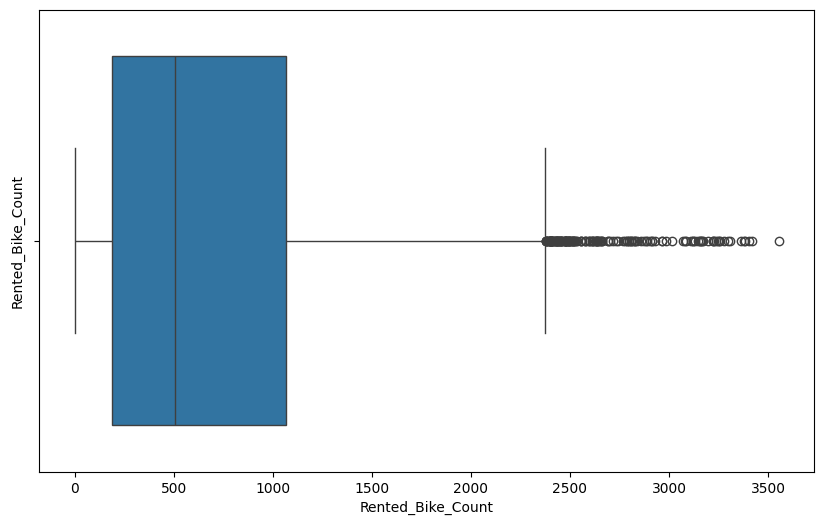

In [95]:
#Boxplot of Rented Bike Count to check outliers
plt.figure(figsize=(10,6))
plt.ylabel('Rented_Bike_Count')
sns.boxplot(x=bike_df['Rented_Bike_Count'])
plt.show()

The above boxplot show that we have detect outliers in the Rented Bike Count.

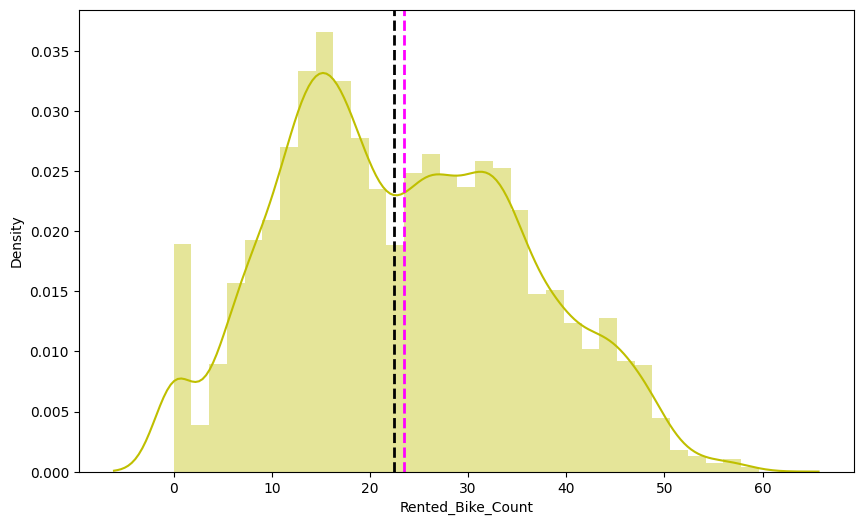

In [96]:
#Applying square root transformation to reduce the skewness of the target variable "Rented_Bike_Count"
plt.figure(figsize=(10,6))
plt.xlabel('Rented_Bike_Count')
plt.ylabel('Density')

ax=sns.distplot(np.sqrt(bike_df['Rented_Bike_Count']),color='y')
ax.axvline(np.sqrt(bike_df['Rented_Bike_Count']).mean(), color='magenta', linestyle='dashed', linewidth=2)
ax.axvline(np.sqrt(bike_df['Rented_Bike_Count']).median(), color='black', linestyle='dashed', linewidth=2)
plt.show()

Since we have generic rule of applying square root for the skewed variable in order to make it normal. After applying Sqaure root to the skewd rented bike count, here we get almost normal distribution.

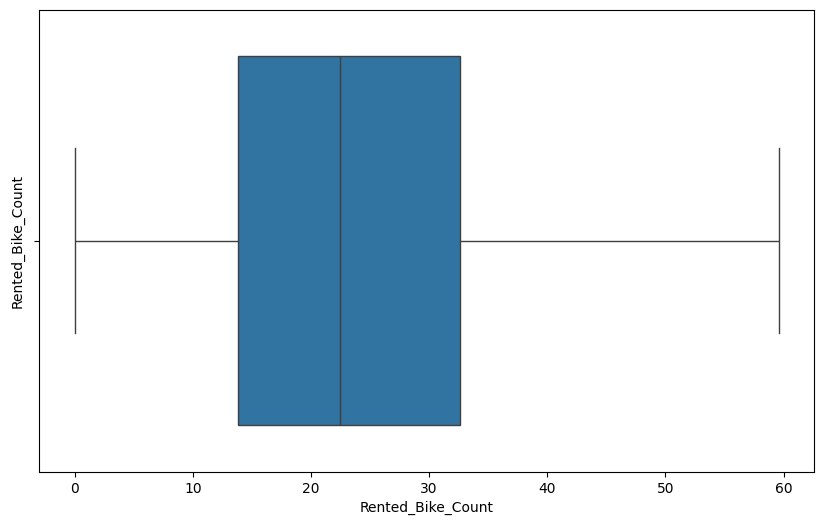

In [97]:
#After applying the square root on rented bike count check whether the we still have outliers.
plt.figure(figsize=(10,6))
plt.ylabel('Rented_Bike_Count')
sns.boxplot(x=np.sqrt(bike_df['Rented_Bike_Count']))
plt.show()

**Checking of Correlation between variables**

Checking in OLS Model

Ordinary least squares (OLS) regression is a statistical method of analysis that estimates the relationship between one or more independent variables and a dependent variable

In [98]:
#import the module
#assign the 'x','y' value
import statsmodels.api as sm
X =bike_df[[ 'Temperature', 'Humidity','Wind_speed', 'Visibility', 'Dew_point_temperature', 'Solar_Radiation', 'Rainfall', 'Snowfall']]
Y=bike_df['Rented_Bike_Count']
bike_df.head()

,Rented_Bike_Count,Hour,Temperature,Humidity,Wind_speed,Visibility,Dew_point_temperature,Solar_Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning_Day,month,weekdays_weekend
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,0
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,0
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,12,0
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,0
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,0


In [99]:
#add a constant column
X = sm.add_constant(X)
X

,const,Temperature,Humidity,Wind_speed,Visibility,Dew_point_temperature,Solar_Radiation,Rainfall,Snowfall
0,1.0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0
1,1.0,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0
2,1.0,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0
3,1.0,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0
4,1.0,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
8755,1.0,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0
8756,1.0,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0
8757,1.0,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0
8758,1.0,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0


In [100]:
#fit a OLS model
model = sm.OLS(Y,X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Rented_Bike_Count   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.397
Method:                 Least Squares   F-statistic:                     723.1
Date:                Sun, 06 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:08:49   Log-Likelihood:                -66877.
No. Observations:                8760   AIC:                         1.338e+05
Df Residuals:                    8751   BIC:                         1.338e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   844.6495    106.296      7.946      0.000     636.285    1053.014
Temperature              36.5270      4.169      8.762      0.000      28.355      44.699
Humidity                -10.5077      1.184     -8.872      0.000     -12.829      -8.186
Wind_speed               52.4810      5.661      9.271      0.000      41.385      63.577
Visibility               -0.0097      0.011     -0.886      0.376      -0.031       0.012
Dew_point_temperature    -0.7829      4.402     -0.178      0.859      -9.411       7.846
Solar_Radiation        -118.9772      8.670    -13.724      0.000    -135.971    -101.983
Rainfall                -50.7083      4.932    -10.282      0.000     -60.376     -41.041
Snowfall                 41.0307     12.806      3.204      0.001      15.929      66.133
==============================================================================
Omnibus:                      957.371   Durbin-Watson:                   0.338
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1591.019
Skew:                           0.769   Prob(JB):                         0.00
Kurtosis:                       4.412   Cond. No.                     3.11e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.11e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [101]:
X.corr()

,const,Temperature,Humidity,Wind_speed,Visibility,Dew_point_temperature,Solar_Radiation,Rainfall,Snowfall
const,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temperature,NaN,1.000000,0.159371,-0.036252,0.034794,0.912798,0.353505,0.050282,-0.218405
Humidity,NaN,0.159371,1.000000,-0.336683,-0.543090,0.536894,-0.461919,0.236397,0.108183
Wind_speed,NaN,-0.036252,-0.336683,1.000000,0.171507,-0.176486,0.332274,-0.019674,-0.003554
Visibility,NaN,0.034794,-0.543090,0.171507,1.000000,-0.176630,0.149738,-0.167629,-0.121695
Dew_point_temperature,NaN,0.912798,0.536894,-0.176486,-0.176630,1.000000,0.094381,0.125597,-0.150887
Solar_Radiation,NaN,0.353505,-0.461919,0.332274,0.149738,0.094381,1.000000,-0.074290,-0.072301
Rainfall,NaN,0.050282,0.236397,-0.019674,-0.167629,0.125597,-0.074290,1.000000,0.008500
Snowfall,NaN,-0.218405,0.108183,-0.003554,-0.121695,-0.150887,-0.072301,0.008500,1.000000


From the OLS model we find that the 'Temperature' and 'Dew_point_temperature' are highly correlated so we need to drop one of them.

For dropping them we need to check the (P>|t|)value from above table and we can see that the 'Dew_point_temperature' value is higher so we need to drop Dew_point_temperature column

For clarity, we use visualisation i.e heatmap in the next step.

In [102]:
#drop the Dew point temperature column
bike_df=bike_df.drop(['Dew_point_temperature'], axis=1)

In [103]:
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Rented_Bike_Count  8760 non-null   int64   
 1   Hour               8760 non-null   category
 2   Temperature        8760 non-null   float64 
 3   Humidity           8760 non-null   int64   
 4   Wind_speed         8760 non-null   float64 
 5   Visibility         8760 non-null   int64   
 6   Solar_Radiation    8760 non-null   float64 
 7   Rainfall           8760 non-null   float64 
 8   Snowfall           8760 non-null   float64 
 9   Seasons            8760 non-null   object  
 10  Holiday            8760 non-null   object  
 11  Functioning_Day    8760 non-null   object  
 12  month              8760 non-null   category
 13  weekdays_weekend   8760 non-null   category
dtypes: category(3), float64(5), int64(3), object(3)
memory usage: 779.7+ KB


**Create the dummy variables**

A dataset may contain various types of values, sometimes it consists of categorical values. So, in-order to use those categorical values for programming efficiently we create dummy variables.

In [105]:
 #Assign all categorical features to a variable
categorical_features=list(bike_df.select_dtypes(['object', 'category']).columns)
categorical_features=pd.Index(categorical_features)
categorical_features

Index(['Hour', 'Seasons', 'Holiday', 'Functioning_Day', 'month',
       'weekdays_weekend'],
      dtype='object')

**One hot encoding**

One hot encoding allows the representation of categorical data to be more expressive. Many machine learning algorithms cannot work with categorical data directly. The categories must be converted into numbers. This is required for both input and output variables that are categorical.

In [107]:
 #creat a copy
bike_df_copy=bike_df
def one_hot_encoding(data, column):

    data=pd.concat([data, pd.get_dummies(data[column], prefix=column, drop_first=True)], axis=1)
    data=data.drop([column], axis=1)
    return data

for col in categorical_features:
    bike_df_copy= one_hot_encoding(bike_df_copy, col)

bike_df_copy.head()

,Rented_Bike_Count,Temperature,Humidity,Wind_speed,Visibility,Solar_Radiation,Rainfall,Snowfall,Hour_1,Hour_2,...,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,weekdays_weekend_1
0,254,-5.2,37,2.2,2000,0.0,0.0,0.0,False,False,...,False,False,False,False,False,False,False,False,True,False
1,204,-5.5,38,0.8,2000,0.0,0.0,0.0,True,False,...,False,False,False,False,False,False,False,False,True,False
2,173,-6.0,39,1.0,2000,0.0,0.0,0.0,False,True,...,False,False,False,False,False,False,False,False,True,False
3,107,-6.2,40,0.9,2000,0.0,0.0,0.0,False,False,...,False,False,False,False,False,False,False,False,True,False
4,78,-6.0,36,2.3,2000,0.0,0.0,0.0,False,False,...,False,False,False,False,False,False,False,False,True,False


**Model Training**

Train Test split for regression

Before, fitting any model it is a rule of thumb to split the dataset into a training and test set. This means some proportions of the data will go into training the model and some portion will be used to evaluate how our model is performing on any unseen data. The proportions may vary from 60:40, 70:30, 75:25 depending on the person but mostly used is 80:20 for training and testing respectively. In this step we will split our data into training and testing set using scikit learn library.

In [112]:
#Assign the value in X and Y
X=bike_df_copy.drop(columns=['Rented_Bike_Count'], axis=1)
y=np.sqrt (bike_df_copy['Rented_Bike_Count'])

In [113]:
#Creat test and train data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.25, random_state=0) 
print(X_train.shape)
print(X_test.shape)

(6570, 47)
(2190, 47)


**LINEAR REGRESSION**


Regression models describe the relationship between variables by fitting a line to the observed data. Linear regression models use a straight line

In [114]:
#import the packages
from sklearn.linear_model import LinearRegression
reg= LinearRegression().fit(X_train, y_train)

In [115]:
#check the score
reg.score(X_train, y_train)

0.7722101548255267

In [116]:
#get the X_train and X-test value
y_pred_train=reg.predict(X_train)
y_pred_test=reg.predict(X_test)

In [117]:
#import the packages
from sklearn.metrics import mean_squared_error

#calculate MSE
MSE_lr=mean_squared_error((y_train), (y_pred_train))
print("MSE :" ,MSE_lr)

#calculate RMSE
RMSE_lr=np.sqrt(MSE_lr)
print("RMSE :", RMSE_lr)

#calculate MAE
MAE_lr= mean_absolute_error(y_train, y_pred_train)
print("MAE :", MAE_lr)

#import the packages
from sklearn.metrics import r2_score

#calculate r2 and adjusted r2
r2_lr= r2_score(y_train, y_pred_train)
print("R2 :",r2_lr)
Adjusted_R2_lr = (1-(1-r2_score(y_train, y_pred_train))*((X_test.shape[0]-1)/(X_test.shape[0]-X_test.shape[1]-1)))
print("Adjusted R2 :",1-(1-r2_score(y_train, y_pred_train))*((X_test.shape[0]-1)/(X_test.shape[0]-X_test.shape[1]-1)))

MSE : 35.07751288189293
RMSE : 5.9226271942350825
MAE : 4.47402409299679
R2 : 0.7722101548255267
Adjusted R2 : 0.7672119649454145
